In [35]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from math import radians, cos, sin, asin, sqrt


In [39]:
# Loading the data
file_paths = [
    'processed_data/2026-03-11.csv',
    'processed_data/2026-03-12.csv',
    'processed_data/2026-03-13.csv',
    'processed_data/2026-03-14.csv'
]

# Read and concatenate all days
df = pd.concat([pd.read_csv(f) for f in file_paths], ignore_index=True)

# Basic Preprocessing
# Convert timestamp to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [20]:
# Data Overview
print("--- Dataset Overview ---")
print(f"Total Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Overview ---
Total Rows: 3,765,046
Columns: ['id', 'timestamp', 'tripId', 'lat', 'lng', 'heading', 'lineId', 'lineName', 'headsign', 'direction']

--- Missing Values ---
id           0
timestamp    0
tripId       0
lat          0
lng          0
heading      0
lineId       0
lineName     0
headsign     0
direction    0
dtype: int64


In [21]:
# Temporal Characterization
print("\n--- Temporal Range ---")
print(f"Start: {df['timestamp'].min()}")
print(f"End:   {df['timestamp'].max()}")
print(f"Duration: {df['timestamp'].max() - df['timestamp'].min()}")


--- Temporal Range ---
Start: 2026-03-11 00:00:07
End:   2026-03-14 23:59:54
Duration: 3 days 23:59:47


In [22]:
# Categorical Cardinality
# Knowing how many unique routes/vehicles are in the data
print("\n--- Unique Counts ---")
stats = {
    "Unique Trips": df['tripId'].nunique(),
    "Unique Lines": df['lineId'].nunique(),
    "Line Names": df['lineName'].nunique(),
    "Directions": df['direction'].unique()
}
for k, v in stats.items():
    print(f"{k}: {v}")


--- Unique Counts ---
Unique Trips: 4660
Unique Lines: 50
Line Names: 50
Directions: [1 0]


In [23]:
# Spatial boundaries
print("\n--- Geospatial Bounds ---")
print(f"Latitude Range:  ({df['lat'].min():.4f}, {df['lat'].max():.4f})")
print(f"Longitude Range: ({df['lng'].min():.4f}, {df['lng'].max():.4f})")


--- Geospatial Bounds ---
Latitude Range:  (-22.9707, -22.8596)
Longitude Range: (-43.1357, -42.9821)


In [24]:
# Sample of Top Lines by Ping Frequency
print("\n--- Top 5 Lines by Activity ---")
print(df['lineName'].value_counts().head(5))


--- Top 5 Lines by Activity ---
lineName
VÁRZEA DAS MOÇAS X CENTRO    200728
RIO DO OURO X CENTRO         196500
OCEÂNICA 3                   186208
MORRO DO CASTRO X NITEROI    172245
SÃO JOSÉ X LEADER            167141
Name: count, dtype: int64


In [25]:
# Visual inspection of the first few rows
df.head()

,id,timestamp,tripId,lat,lng,heading,lineId,lineName,headsign,direction
0,52243,2026-03-11 00:00:07,1476582_U_37,-22.875029,-43.038486,322.00000,52,BALDEADOR X ITAIPU (VIA CANTAGALO),52 BALDEADOR,1
1,52272,2026-03-11 00:00:07,1483711_U_195,-22.912451,-43.078884,92.60256,33,JURUJUBA X TERMINAL RODOVIARIO,33 TERMINAL RODOVIÁRIO,0
2,69020,2026-03-11 00:00:07,1345046_U_36,-22.890236,-43.124805,352.20000,39A,PIRATININGA X CENTRO,39A Piratininga (Cafubá),1
3,69050,2026-03-11 00:00:07,1393827_U_152,-22.895660,-43.124977,236.50000,45,CUBANGO X CENTRO,45 Cubango,1
4,69121,2026-03-11 00:00:07,1414833_U_72,-22.932734,-43.098888,50.30000,OC1,OCEÂNICA 1,OC1 Piratininga,1


/tmp/ipykernel_5049/835777374.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  throughput = df.set_index('timestamp').resample('5T').size()


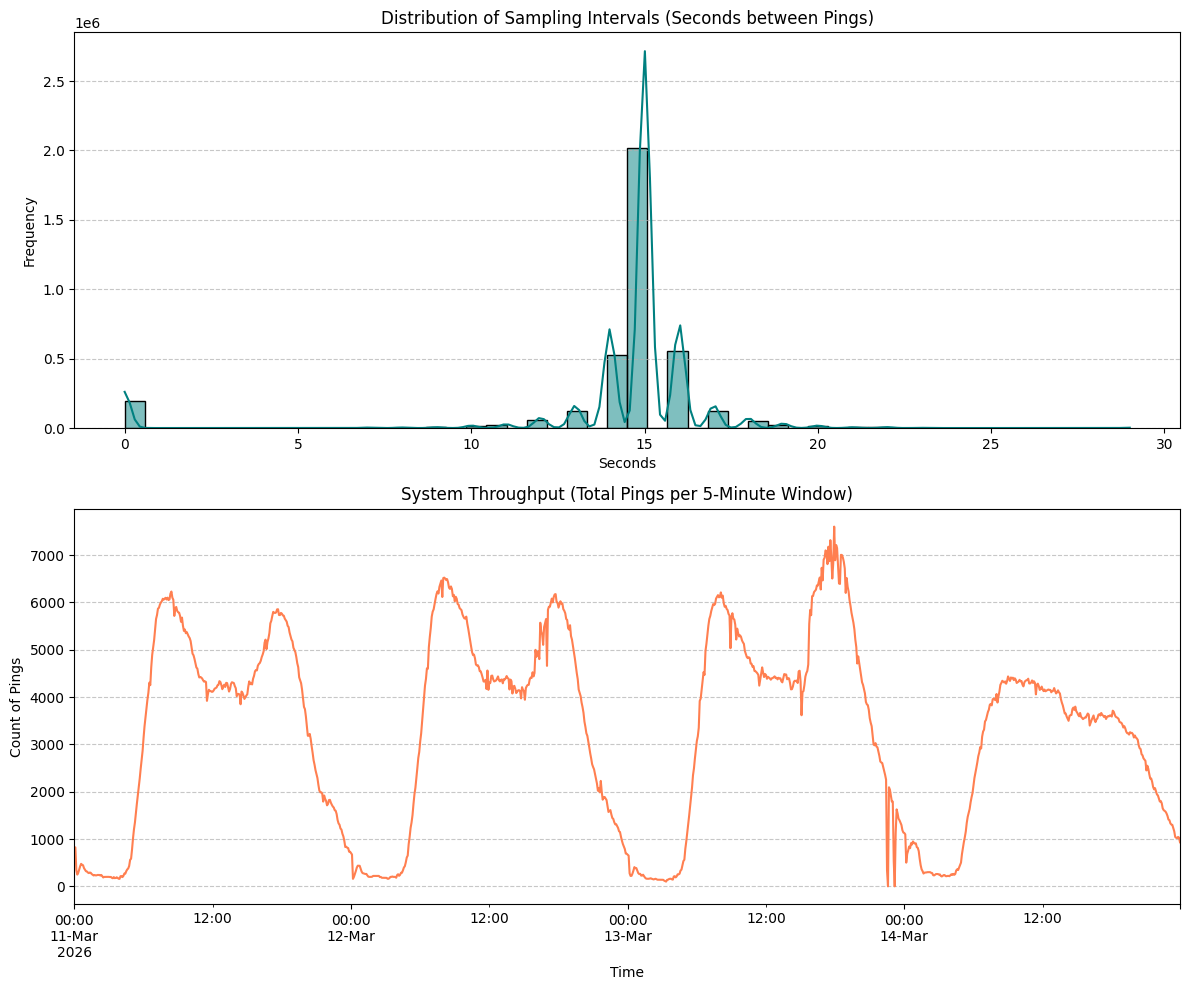

--- Sampling Rate Statistics ---
Median interval: 15.00 seconds
Mean interval:   14.24 seconds
90th Percentile: 16.00 seconds


In [26]:
# Calculate intervals (Sampling Rate per Trip)
# We sort by trip and time to ensure we calculate the delta between consecutive pings of the same trip
df = df.sort_values(by=['tripId', 'timestamp'])

# Calculate the difference in time between rows
df['time_diff'] = df.groupby('tripId')['timestamp'].diff().dt.total_seconds()

# Filter out the first ping of every trip (which will be NaN) 
# and potentially huge gaps (e.g., > 10 mins) which represent trip restarts or data loss
sampling_intervals = df['time_diff'].dropna()
sampling_intervals = sampling_intervals[sampling_intervals < 30] # Focus on intervals < 10 minutes

# Aggregate throughput (System Sampling Density)
# Count pings per 5-minute window
throughput = df.set_index('timestamp').resample('5T').size()

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Distribution of intervals
sns.histplot(sampling_intervals, bins=50, kde=True, ax=ax1, color='teal')
ax1.set_title('Distribution of Sampling Intervals (Seconds between Pings)')
ax1.set_xlabel('Seconds')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: System throughput over time
throughput.plot(ax=ax2, color='coral')
ax2.set_title('System Throughput (Total Pings per 5-Minute Window)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Count of Pings')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print("--- Sampling Rate Statistics ---")
print(f"Median interval: {sampling_intervals.median():.2f} seconds")
print(f"Mean interval:   {sampling_intervals.mean():.2f} seconds")
print(f"90th Percentile: {sampling_intervals.quantile(0.9):.2f} seconds")

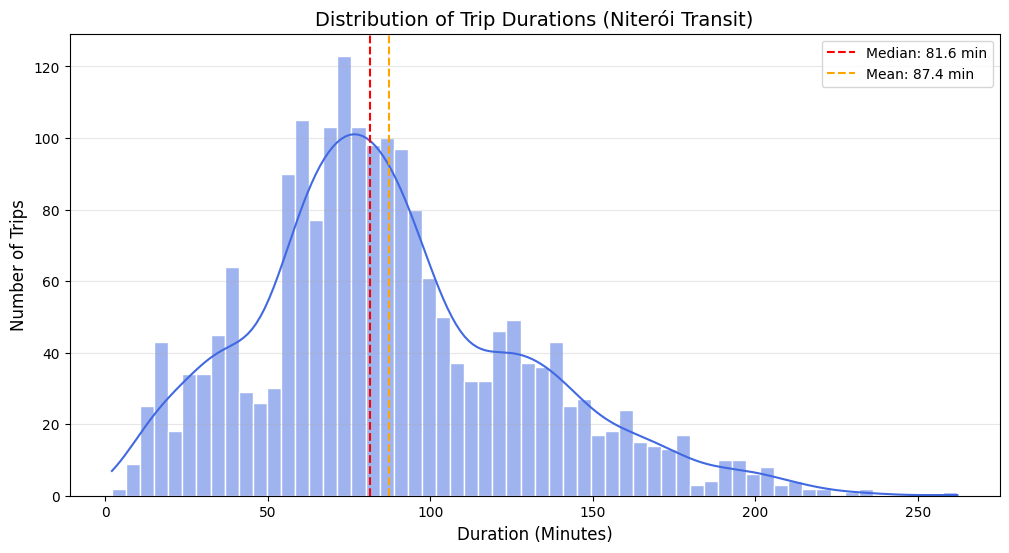

--- Trip Duration Statistics (Minutes) ---
count    1984.000000
mean       87.416213
std        42.124824
min         2.016667
25%        59.816667
50%        81.566667
75%       111.545833
max       262.233333
Name: duration_min, dtype: float64


In [27]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Calculate Durations per Trip
# Group by tripId and find the start and end times
trip_stats = df.groupby('tripId')['timestamp'].agg(['min', 'max'])

# Calculate duration in minutes
trip_stats['duration_min'] = (trip_stats['max'] - trip_stats['min']).dt.total_seconds() / 60.0

# Filter Outliers
# We exclude 0-minute trips (single pings) and trips longer than 5 hours (likely data errors)
filtered_durations = trip_stats[(trip_stats['duration_min'] > 1) & (trip_stats['duration_min'] < 300)]['duration_min']

# Plotting the Distribution
plt.figure(figsize=(12, 6))
sns.histplot(filtered_durations, bins=60, kde=True, color='royalblue', edgecolor='white')

# Adding statistical vertical lines
plt.axvline(filtered_durations.median(), color='red', linestyle='--', label=f'Median: {filtered_durations.median():.1f} min')
plt.axvline(filtered_durations.mean(), color='orange', linestyle='--', label=f'Mean: {filtered_durations.mean():.1f} min')

plt.title('Distribution of Trip Durations (Niterói Transit)', fontsize=14)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print Descriptive Statistics
print("--- Trip Duration Statistics (Minutes) ---")
print(filtered_durations.describe())

In [40]:
# Haversine function (same as before)
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371

# Grouping by tripId
# Note: In GTFS-RT, tripIds are usually unique per day. 
# To be safe across multiple days, we group by tripId AND the date.
df['date'] = df['timestamp'].dt.date

trip_stats = df.sort_values(['tripId', 'timestamp']).groupby(['tripId', 'date']).agg(
    lineId=('lineId', 'first'),
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max'),
    start_lat=('lat', 'first'),
    start_lng=('lng', 'first'),
    end_lat=('lat', 'last'),
    end_lng=('lng', 'last')
).reset_index()

# Calculate Metrics
trip_stats['duration_min'] = (trip_stats['end_time'] - trip_stats['start_time']).dt.total_seconds() / 60
trip_stats['dist_km'] = trip_stats.apply(lambda x: haversine(x.start_lng, x.start_lat, x.end_lng, x.end_lat), axis=1)

# Filter Noise
# Removing "trips" that are essentially GPS noise (too short in time or distance)
trip_stats = trip_stats[(trip_stats['duration_min'] > 5) & (trip_stats['dist_km'] > 0.5)]

print(f"Successfully characterized {len(trip_stats)} trips.")

Successfully characterized 5416 trips.


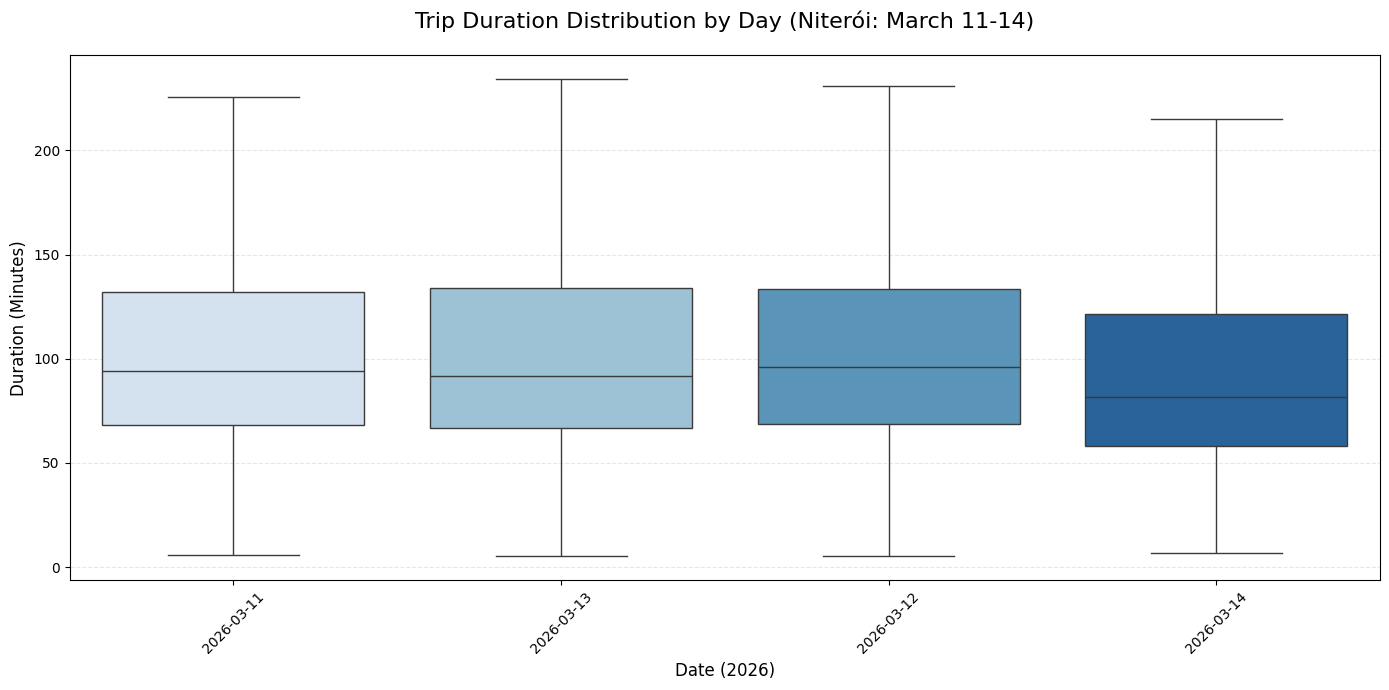

Number of valid trips characterized per day:
date
2026-03-11    1606
2026-03-12    1595
2026-03-13    1339
2026-03-14     876
dtype: int64


In [43]:
# Loading the data
file_paths = [
    'processed_data/2026-03-11.csv',
    'processed_data/2026-03-12.csv',
    'processed_data/2026-03-13.csv',
    'processed_data/2026-03-14.csv'
]

# Read and concatenate all days
df = pd.concat([pd.read_csv(f) for f in file_paths], ignore_index=True)

# Basic Preprocessing
# Convert timestamp to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Setting up the visualization
plt.figure(figsize=(14, 7))

# Creating the Boxplot
# We assign hue=date to remove the warning and legend=False because the x-axis already shows the date
sns.boxplot(
    data=trip_stats, 
    x='date', 
    y='duration_min', 
    hue='date',          # This fixes the warning
    legend=False,        # Removes unnecessary legend
    palette="Blues", 
    showfliers=False     # Hiding extreme outliers to see the distribution clearly
)

# Customizing the labels
plt.title('Trip Duration Distribution by Day (Niterói: March 11-14)', fontsize=16, pad=20)
plt.xlabel('Date (2026)', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical Summary to check for missing data
daily_counts = trip_stats.groupby('date').size()
print("Number of valid trips characterized per day:")
print(daily_counts)

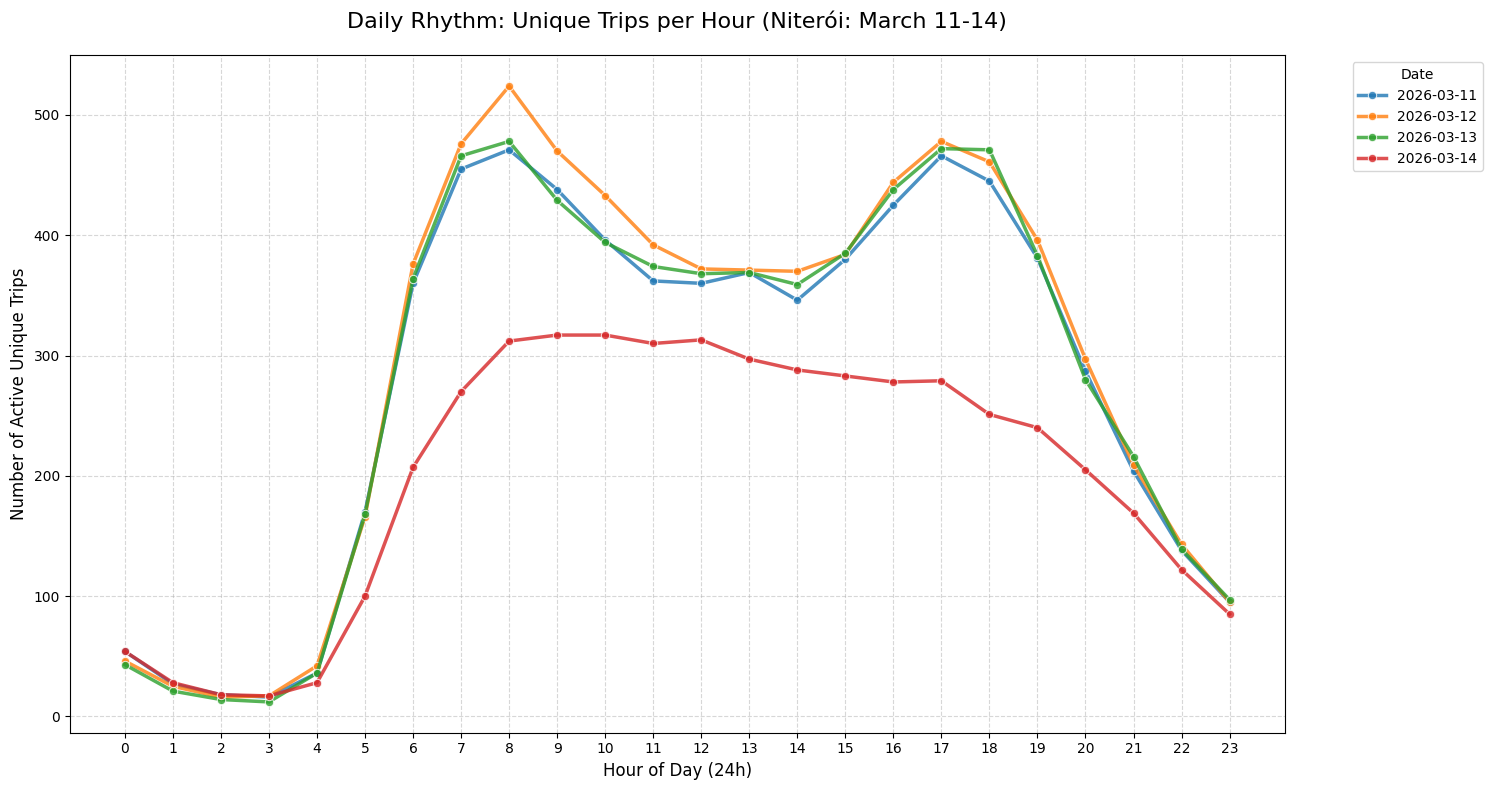

In [44]:
# Ensure time columns exist
df['hour'] = df['timestamp'].dt.hour
df['date_str'] = df['timestamp'].dt.strftime('%Y-%m-%d') # For cleaner legend

# Group by date and hour to count unique tripIds
hourly_trips = df.groupby(['date_str', 'hour'])['tripId'].nunique().reset_index(name='unique_trips')

# Visualization
plt.figure(figsize=(15, 8))

# We use a lineplot with hue='date_str' to get one line per day
sns.lineplot(
    data=hourly_trips, 
    x='hour', 
    y='unique_trips', 
    hue='date_str', 
    marker='o',      # Adds dots at each hour for precision
    linewidth=2.5,
    alpha=0.8
)

# 4. Formatting the chart
plt.title('Daily Rhythm: Unique Trips per Hour (Niterói: March 11-14)', fontsize=16, pad=20)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Active Unique Trips', fontsize=12)
plt.xticks(range(0, 24)) # Ensure every hour is marked
plt.grid(True, linestyle='--', alpha=0.5)

# Move legend outside to keep the plot clean
plt.legend(title='Date', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

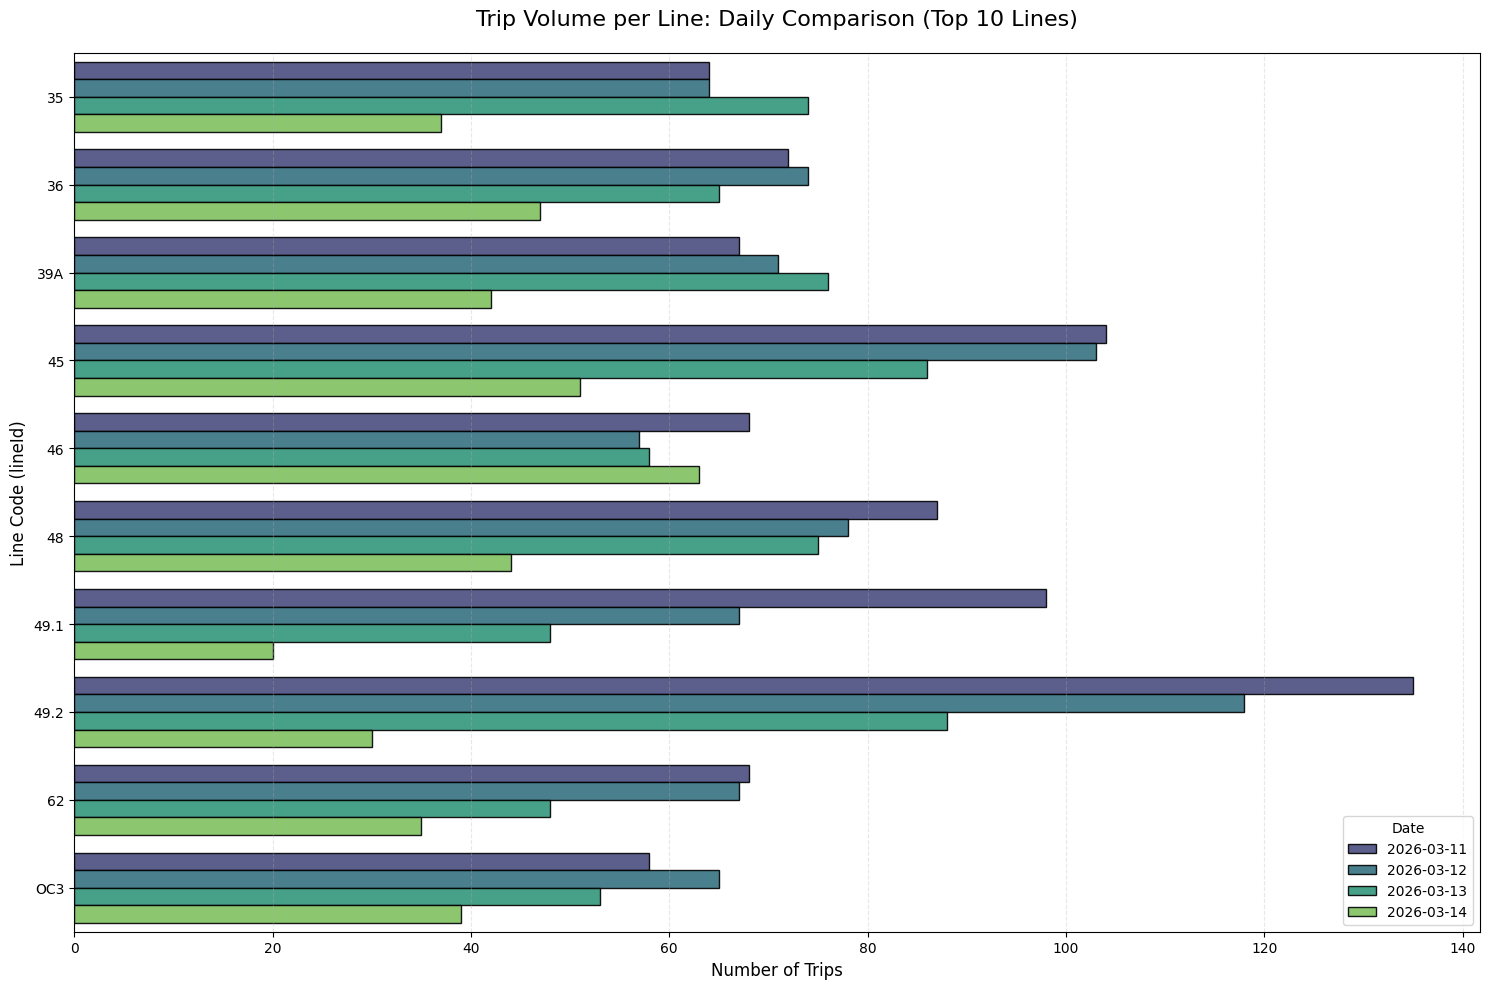

In [47]:
# Count trips per line and per day
line_day_counts = trip_stats.groupby(['lineId', 'date']).size().reset_index(name='trip_count')

# Identify the Top 10 lines (based on total volume) to keep the plot clean
top_10_overall = trip_stats['lineId'].value_counts().head(10).index
line_day_filtered = line_day_counts[line_day_counts['lineId'].isin(top_10_overall)]

# Visualization
plt.figure(figsize=(15, 10))

# We use 'linha' on Y and 'trip_count' on X, with 'date' as the hue
sns.barplot(
    data=line_day_filtered,
    x='trip_count',
    y='lineId',
    hue='date',
    palette='viridis',
    edgecolor='black',
    alpha=0.9
)

# 4. Formatting
plt.title('Trip Volume per Line: Daily Comparison (Top 10 Lines)', fontsize=16, pad=20)
plt.xlabel('Number of Trips', fontsize=12)
plt.ylabel('Line Code (lineId)', fontsize=12)
plt.legend(title='Date', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

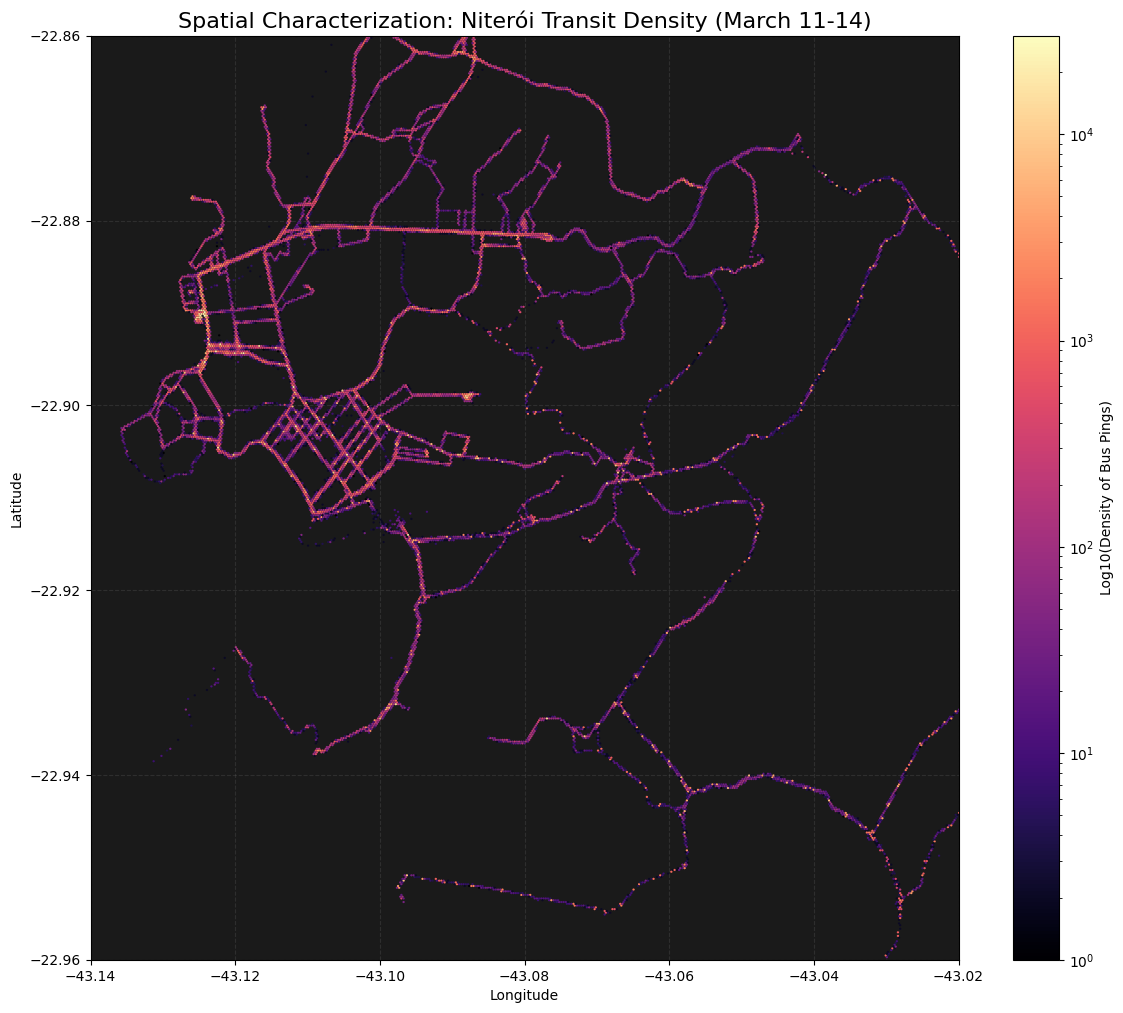

In [48]:
plt.figure(figsize=(14, 12))

# Using a high gridsize (500) to see individual streets
hb = plt.hexbin(
    df['lng'], 
    df['lat'], 
    gridsize=500, 
    cmap='magma', 
    bins='log',
    mincnt=1,
    edgecolors='none'
)

# Adding the colorbar with a label
cb = plt.colorbar(hb, label='Log10(Density of Bus Pings)')

# Niterói Focus Coordinates
plt.xlim(-43.14, -43.02)
plt.ylim(-22.96, -22.86)

plt.title('Spatial Characterization: Niterói Transit Density (March 11-14)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Style the plot to look like a map
plt.gca().set_facecolor('#1a1a1a') # Dark background makes the 'magma' colors pop
plt.grid(True, color='gray', linestyle='--', alpha=0.2)

plt.show()

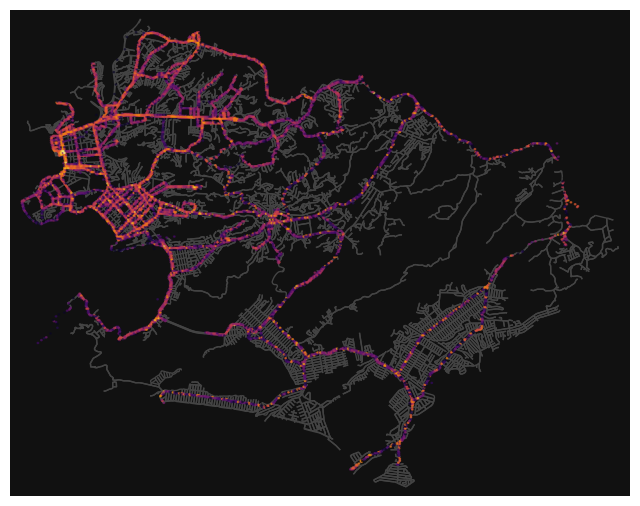

In [49]:
import osmnx as ox

# 1. Download the Niterói street network (drive)
# You can use a point and distance, or a name
G = ox.graph_from_place('Niterói, Brazil', network_type='drive')

# 2. Plot the network
fig, ax = ox.plot_graph(G, node_size=0, edge_color='#444444', bgcolor='#111111', show=False, close=False)

# 3. Overlay your bus pings (Hexbin) on the actual streets
hb = ax.hexbin(df['lng'], df['lat'], gridsize=400, cmap='inferno', bins='log', alpha=0.6)
plt.show()